# Análisis de frecuencias hidrológicas

## Máximos anuales, estimación de parámetros, bondad de ajuste y periodos de retorno

Este notebook trabaja con un archivo Excel estructurado en pestañas por río. El objetivo es:

1. Leer y revisar las hojas del Excel.
2. Extraer máximos anuales por río.
3. Calcular estadística descriptiva.
4. Estimar parámetros de distribuciones probabilísticas.
5. Evaluar bondad de ajuste.
6. Calcular caudales asociados a periodos de retorno.
7. Exportar resultados.

Distribuciones incluidas:

- Gumbel por método de momentos.
- Gumbel por máxima verosimilitud.
- Exponencial de 1 parámetro.
- Exponencial de 2 parámetros.
- GEV por máxima verosimilitud.

> Nota: TCEV no se implementa directamente porque requiere un ajuste numérico más delicado y suele necesitar una muestra suficientemente larga. Se deja indicado al final cómo integrarla si el profesor la exige.

# 0. Instalación de librerías

Ejecuta esta celda solo si te falta alguna librería. Si ya las tienes instaladas, puedes saltarla.

In [ ]:
# Si estás usando conda, es mejor instalar desde terminal:
# conda install pandas numpy scipy matplotlib openpyxl

# Si usas pip, puedes descomentar esta línea:
# !pip install pandas numpy scipy matplotlib openpyxl

# 1. Librerías y configuración inicial

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy import stats

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Cambia esta ruta por la ruta real de tu archivo Excel
EXCEL_PATH = r"C:\Users\luist\Desktop\entregas-Riobravo\DATA\Entregas Historicas.xlsx"

# Carpeta de salida
OUTPUT_DIR = Path("resultados_frecuencias")
OUTPUT_DIR.mkdir(exist_ok=True)

EXCEL_PATH

'C:\\Users\\luist\\Desktop\\entregas-Series\\DATA\\Entregas Historicas.xlsx'

# 2. Revisar hojas disponibles en el Excel

In [3]:
excel = pd.ExcelFile(EXCEL_PATH)
excel.sheet_names

['6 Tributarios',
 'Conchos',
 'Vacas',
 'San Diego',
 'San Rodrigo',
 'Escondido',
 'Salado',
 'Base de Datos',
 'Oct2025']

# 3. Definir hojas que entran al análisis

Según la estructura descrita:

- `6 Tributarios`: suma total de los 6 ríos.
- `Conchos`, `Vacas`, `San Diego`, `San Rodrigo`, `Escondido`, `Salado`: hojas individuales.
- `Base de Datos`: base mensual completa separada por río.
- `Oct2025`: métricas diarias de octubre de 2025.

Para análisis de máximos anuales se usarán primero las hojas individuales y la suma de tributarios. `Base de Datos` y `Oct2025` se dejan fuera porque tienen otra granularidad.

In [4]:
hojas_analisis = [
    "6 Tributarios",
    "Conchos",
    "Vacas",
    "San Diego",
    "San Rodrigo",
    "Escondido",
    "Salado"
]

# Validar cuáles existen realmente en el Excel
hojas_existentes = [h for h in hojas_analisis if h in excel.sheet_names]
hojas_faltantes = [h for h in hojas_analisis if h not in excel.sheet_names]

print("Hojas encontradas:", hojas_existentes)
print("Hojas faltantes:", hojas_faltantes)

Hojas encontradas: ['6 Tributarios', 'Conchos', 'Vacas', 'San Diego', 'San Rodrigo', 'Escondido', 'Salado']
Hojas faltantes: []


# 4. Inspección manual de una hoja

Antes de automatizar, revisamos una pestaña. Esto permite confirmar si las columnas son años y las filas son meses.

In [5]:
hoja_prueba = "Conchos"

df_prueba = pd.read_excel(EXCEL_PATH, sheet_name=hoja_prueba)
df_prueba.head(15)

,Río Conchos,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,ENERO,NaN,12.869667,7.277667,5.879667,4.746333,5.690333,6.649000,8.195000,7.210667,15.186333,21.277333,24.362000,11.163333,11.657333,8.344333,12.415667,8.617667,12.501333,8.173667,53.982667,10.745333,11.776333,38.611667,8.958000,9.694000,10.679000,8.706667,5.916667,6.116667,23.339667,7.303000,20.142667,12.669000,4.676667,10.746000,11.843000,9.307000,5.669000,8.088667,10.529333,5.419333,17.686000,87.886000,4.498000,11.713000,1.661667,0.705000,1.014000,1.264333,1.091333,1.850000,15.425333,0.368000,0.312333,3.501667,6.442000,0.637333,1.366333,0.727333,3.600000,1.309667,0.679333,0.503000,2.274000,6.852667,2.712000,1.533333,15.411000,3.187667,0.584333,5.903667,1.435392,0.241632,2.733408,0.380160,0.147168
1,FEBRERO,19.941667,21.750667,5.592000,4.646333,4.378333,4.835667,7.751000,8.693667,6.420667,7.826333,29.713000,17.084000,8.440000,7.737000,9.720667,13.035000,7.508000,9.380000,1.371667,51.143000,9.316333,11.658333,11.586333,6.587333,7.910000,35.320333,4.007333,4.190333,5.663667,20.237667,6.626000,30.274667,14.682333,4.488667,13.855667,10.952667,6.881333,8.361333,7.609000,10.863333,15.494000,19.028000,70.159667,3.628667,10.301667,1.094000,0.657333,1.382333,0.928333,1.160000,1.986333,8.148000,0.325000,1.384333,0.788000,9.357667,0.465333,0.647333,0.710333,1.697667,25.243333,0.602333,0.332667,0.223333,3.203333,1.663333,0.561333,5.458333,1.989000,1.059000,0.570333,0.491616,0.213984,2.130912,0.159552,0.106848
2,MARZO,20.106000,16.117667,4.099333,3.519667,2.223000,2.609667,5.234000,5.229667,3.813000,7.832000,21.185333,13.382333,8.244000,6.276000,10.181333,10.348333,5.047000,9.281000,1.715000,53.573667,7.489000,11.106000,19.391000,4.016000,10.705667,82.733667,3.781000,25.806667,4.924000,39.398333,15.421667,37.733667,22.766333,5.435333,8.055333,12.438667,8.478000,35.582333,5.685333,7.974667,16.421667,26.199333,29.978000,5.238000,13.167333,0.996333,0.450667,1.215333,1.078667,1.292000,3.255667,1.564000,0.737000,0.290000,20.223667,2.178000,6.042667,18.841667,1.237333,2.568000,2.195667,0.767000,0.554000,0.385000,1.397333,3.465667,0.871333,0.795667,0.852667,6.851333,0.685000,0.462240,0.242784,1.180512,0.179424,0.145728
3,ABRIL,7.401000,6.825333,1.324000,0.351667,0.380333,0.115667,1.163667,2.896000,0.589333,7.134333,9.313667,5.557000,3.893000,4.407000,4.803000,4.997333,2.671667,5.195000,3.797000,31.395000,4.883000,7.836333,16.655000,2.846000,17.894333,35.447000,2.288000,35.965333,26.640667,36.953333,15.938000,33.148667,32.837667,7.823333,4.813333,11.877333,6.669000,32.593000,6.255667,5.883667,8.440333,27.106667,26.668667,5.031667,14.423333,3.294667,0.386000,0.996333,1.517333,1.817333,1.760333,1.804333,1.464667,0.434333,1.240000,1.163667,10.054000,5.777667,0.903333,1.248667,1.834333,0.927333,1.237000,0.580000,0.903333,0.689000,0.612333,0.793667,0.796667,5.525667,0.774000,0.653472,0.239040,1.184256,0.373824,0.160704
4,MAYO,8.017667,12.993000,2.076333,0.921000,0.642333,0.131333,2.639333,11.176000,1.592667,9.291667,6.608667,8.250000,3.728000,7.967333,7.158667,5.381333,6.149000,7.991333,4.495000,10.990333,5.284333,7.855333,18.895667,8.323333,50.881000,13.573333,8.079000,35.602667,31.449667,38.525667,29.718667,19.601333,40.988000,28.189333,12.947333,14.575667,9.088000,29.955000,10.807667,10.290333,8.287667,20.036000,70.410333,6.032333,31.037667,1.538333,0.349000,17.984333,2.987333,2.814333,4.865667,2.150667,1.177667,1.194000,2.114333,2.318333,4.778000,7.601667,1.175333,32.273333,1.013667,1.083333,4.111333,1.765000,0.813000,0.906667,3.431333,6.002333,2.063667,1.210000,1.480000,1.295424,0.277920,9.030816,0.323424,1.651968
5,JUNIO,16.981333,15.377667,19.571667,1.9860

In [6]:
df_prueba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 77 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Río Conchos  12 non-null     object 
 1   1950         11 non-null     float64
 2   1951         12 non-null     float64
 3   1952         12 non-null     float64
 4   1953         12 non-null     float64
 5   1954         12 non-null     float64
 6   1955         12 non-null     float64
 7   1956         12 non-null     float64
 8   1957         12 non-null     float64
 9   1958         12 non-null     float64
 10  1959         12 non-null     float64
 11  1960         12 non-null     float64
 12  1961         12 non-null     float64
 13  1962         12 non-null     float64
 14  1963         12 non-null     float64
 15  1964         12 non-null     float64
 16  1965         12 non-null     float64
 17  1966         12 non-null     float64
 18  1967         12 non-null     float64
 19  1968      

# 5. Funciones de limpieza y extracción de máximos anuales

La función principal asume que las columnas son años y las filas son meses. Si tu Excel viene invertido, el notebook incluye una alternativa automática básica.

In [7]:
def detectar_columnas_anio(df):
    """Detecta columnas que representan años entre 1800 y 2100."""
    columnas_anio = []
    renombrar = {}
    
    for col in df.columns:
        col_str = str(col).strip()
        try:
            anio = int(float(col_str))
            if 1800 <= anio <= 2100:
                columnas_anio.append(col)
                renombrar[col] = anio
        except Exception:
            pass
    
    return columnas_anio, renombrar


def limpiar_hoja(df):
    """Elimina filas/columnas vacías y normaliza encabezados."""
    df = df.copy()
    df = df.dropna(axis=0, how="all")
    df = df.dropna(axis=1, how="all")
    df.columns = [str(c).strip() for c in df.columns]
    return df


def extraer_maximos_anuales(EXCEL_PATH, sheet_name):
    """
    Extrae máximos anuales de una hoja donde las columnas son años y las filas son meses.
    Devuelve DataFrame: Rio, Anio, Maximo_Anual.
    """
    df = pd.read_excel(EXCEL_PATH, sheet_name=sheet_name)
    df = limpiar_hoja(df)
    
    columnas_anio, renombrar = detectar_columnas_anio(df)
    
    # Si detectó columnas de año, trabajamos directamente
    if len(columnas_anio) > 0:
        df = df.rename(columns=renombrar)
        columnas_anio = list(renombrar.values())
        datos = df[columnas_anio].apply(pd.to_numeric, errors="coerce")
        maximos = datos.max(axis=0, skipna=True)
        
        resultado = pd.DataFrame({
            "Rio": sheet_name,
            "Anio": [int(x) for x in maximos.index],
            "Maximo_Anual": maximos.values
        })
        
        resultado = resultado.dropna(subset=["Maximo_Anual"])
        resultado = resultado.sort_values("Anio").reset_index(drop=True)
        return resultado
    
    # Si no detectó años como columnas, intentamos estructura invertida:
    # una columna puede contener años y el resto meses.
    for col in df.columns:
        serie = pd.to_numeric(df[col], errors="coerce")
        posibles_anios = serie.dropna().astype(int)
        if len(posibles_anios) > 0 and posibles_anios.between(1800, 2100).mean() > 0.8:
            col_anio = col
            columnas_valores = [c for c in df.columns if c != col_anio]
            valores = df[columnas_valores].apply(pd.to_numeric, errors="coerce")
            maximos = valores.max(axis=1, skipna=True)
            
            resultado = pd.DataFrame({
                "Rio": sheet_name,
                "Anio": serie.astype("Int64"),
                "Maximo_Anual": maximos.values
            })
            
            resultado = resultado.dropna(subset=["Anio", "Maximo_Anual"])
            resultado["Anio"] = resultado["Anio"].astype(int)
            resultado = resultado.sort_values("Anio").reset_index(drop=True)
            return resultado
    
    raise ValueError(f"No se pudo detectar estructura de años en la hoja: {sheet_name}")

# 6. Probar extracción con una hoja

In [8]:
max_prueba = extraer_maximos_anuales(EXCEL_PATH, hoja_prueba)
max_prueba.head(), max_prueba.tail()

(       Rio  Anio  Maximo_Anual
 0  Conchos  1950     41.528000
 1  Conchos  1951     21.750667
 2  Conchos  1952     82.644667
 3  Conchos  1953      9.662333
 4  Conchos  1954     54.242667,
         Rio  Anio  Maximo_Anual
 71  Conchos  2021      8.953344
 72  Conchos  2022    157.685760
 73  Conchos  2023      9.030816
 74  Conchos  2024      8.365536
 75  Conchos  2025     34.665984)

# 7. Extraer máximos anuales de todas las hojas

In [9]:
series_maximos = []

for hoja in hojas_existentes:
    try:
        temp = extraer_maximos_anuales(EXCEL_PATH, hoja)
        series_maximos.append(temp)
        print(f"OK: {hoja} -> {len(temp)} años")
    except Exception as e:
        print(f"ERROR en {hoja}: {e}")

maximos_anuales = pd.concat(series_maximos, ignore_index=True)
maximos_anuales.head(20)

OK: 6 Tributarios -> 76 años
OK: Conchos -> 76 años
OK: Vacas -> 76 años
OK: San Diego -> 76 años
OK: San Rodrigo -> 76 años
OK: Escondido -> 76 años
OK: Salado -> 76 años


,Rio,Anio,Maximo_Anual
0,6 Tributarios,1950,47.604000
1,6 Tributarios,1951,51.386000
2,6 Tributarios,1952,83.844433
3,6 Tributarios,1953,145.845000
4,6 Tributarios,1954,58.384107
5,6 Tributarios,1955,89.918667
6,6 Tributarios,1956,28.373333
7,6 Tributarios,1957,67.771667
8,6 Tributarios,1958,693.992667
9,6 Tributarios,1959,67.017000


# 8. Validación básica de máximos anuales

Aquí revisamos si hay valores faltantes, negativos o series demasiado cortas.

In [10]:
validacion = (
    maximos_anuales
    .groupby("Rio")
    .agg(
        n=("Maximo_Anual", "count"),
        anio_min=("Anio", "min"),
        anio_max=("Anio", "max"),
        faltantes=("Maximo_Anual", lambda x: x.isna().sum()),
        negativos=("Maximo_Anual", lambda x: (x < 0).sum()),
        ceros=("Maximo_Anual", lambda x: (x == 0).sum())
    )
    .reset_index()
)

validacion

,Rio,n,anio_min,anio_max,faltantes,negativos,ceros
0,6 Tributarios,76,1950,2025,0,0,0
1,Conchos,76,1950,2025,0,0,0
2,Escondido,76,1950,2025,0,0,0
3,Salado,76,1950,2025,0,0,0
4,San Diego,76,1950,2025,0,0,0
5,San Rodrigo,76,1950,2025,0,0,1
6,Vacas,76,1950,2025,0,0,0


# 9. Estadística descriptiva por río

In [11]:
def coef_variacion(x):
    return np.std(x, ddof=1) / np.mean(x) if np.mean(x) != 0 else np.nan

resumen = (
    maximos_anuales
    .groupby("Rio")["Maximo_Anual"]
    .agg(
        n="count",
        minimo="min",
        media="mean",
        mediana="median",
        desviacion="std",
        maximo="max",
        asimetria=lambda x: stats.skew(x, nan_policy="omit"),
        curtosis=lambda x: stats.kurtosis(x, nan_policy="omit"),
        coef_variacion=coef_variacion
    )
    .reset_index()
)

resumen

,Rio,n,minimo,media,mediana,desviacion,maximo,asimetria,curtosis,coef_variacion
0,6 Tributarios,76,11.536992,143.868600,76.700167,195.984037,1384.020333,4.072274,20.576940,1.362243
1,Conchos,76,6.720667,75.566033,40.969333,101.692551,624.447333,3.271735,12.275629,1.345744
2,Escondido,76,0.127008,5.552419,3.321833,8.689508,58.415333,4.292240,21.201982,1.564995
3,Salado,76,1.268928,49.400482,19.048000,111.446353,877.986000,5.823946,38.998172,2.255977
4,San Diego,76,1.341667,15.092699,11.153833,18.645542,142.897000,4.614473,27.615150,1.235401
5,San Rodrigo,76,0.000000,18.632532,6.702167,38.808213,268.246333,4.768993,25.148788,2.082820
6,Vacas,76,0.130752,3.414232,1.495833,5.988652,41.152333,4.370785,21.851684,1.754026


# 10. Gráficas exploratorias

Primero se grafican las series de máximos anuales por río.

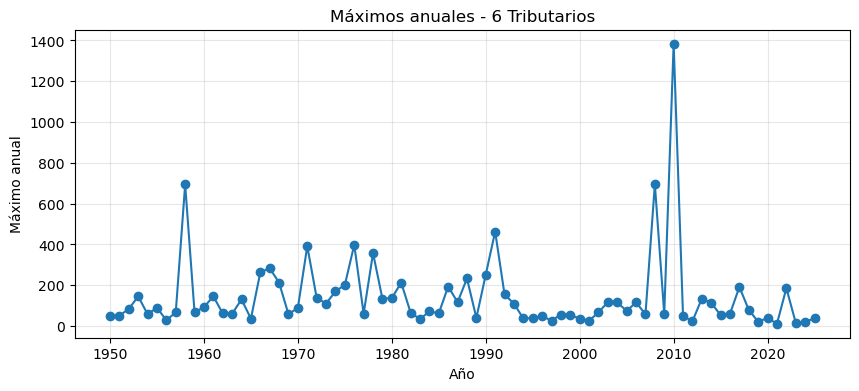

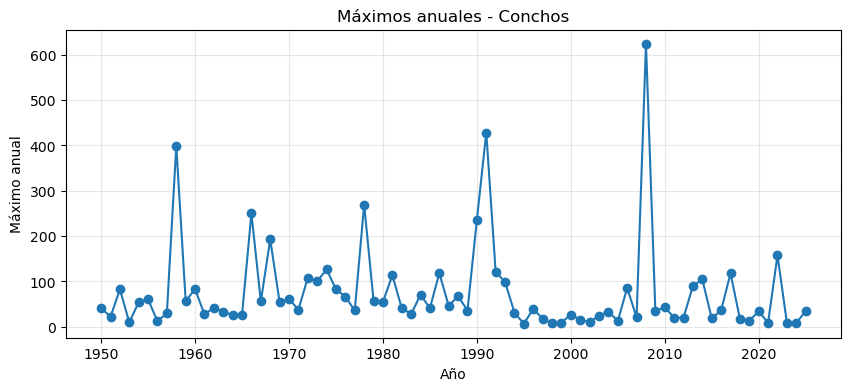

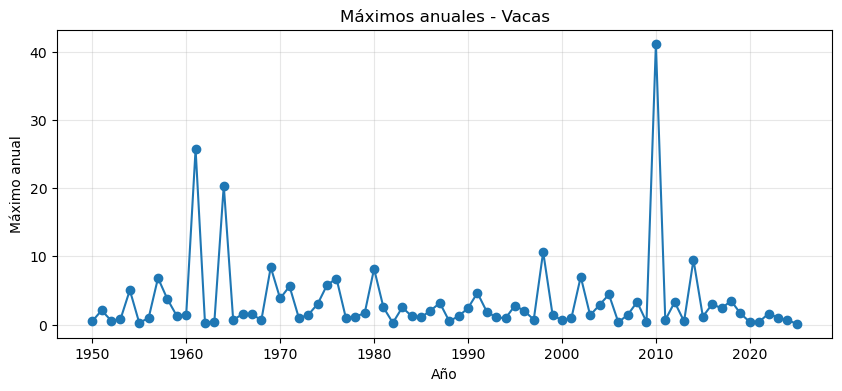

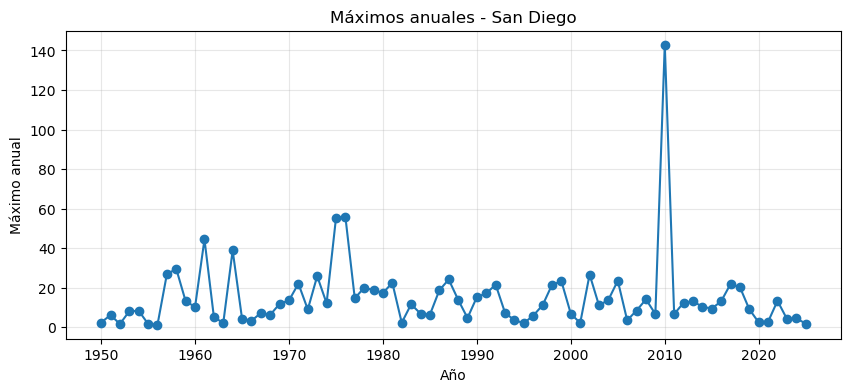

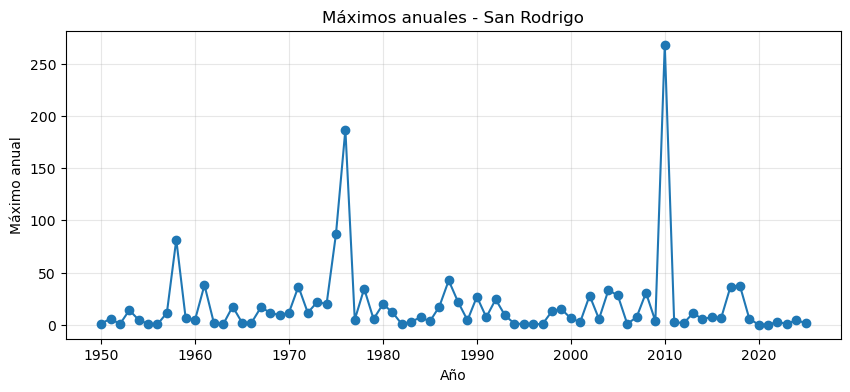

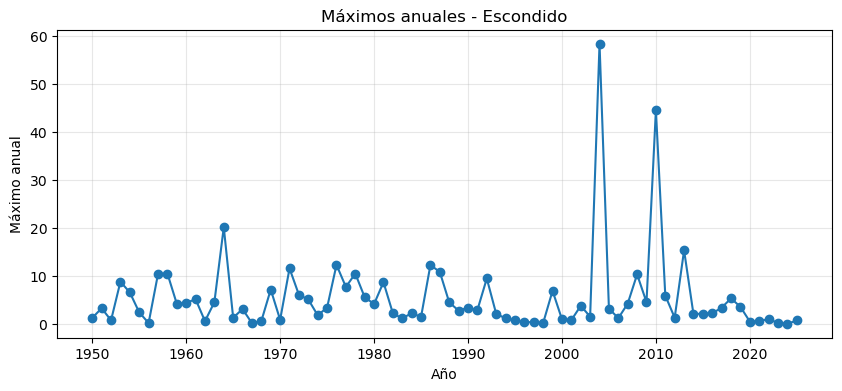

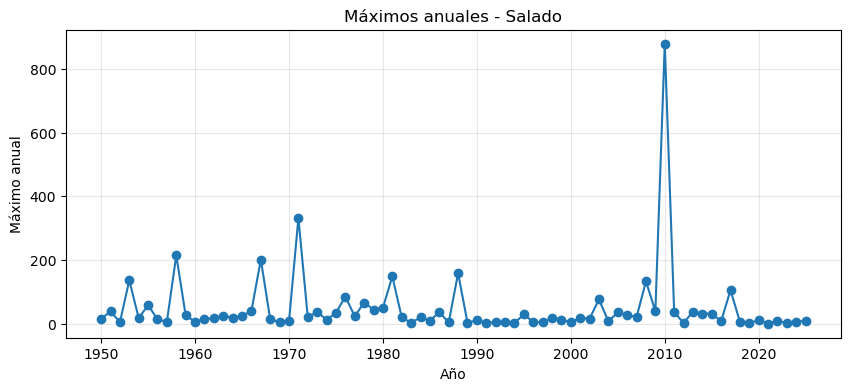

In [12]:
for rio in maximos_anuales["Rio"].unique():
    temp = maximos_anuales[maximos_anuales["Rio"] == rio]
    
    plt.figure(figsize=(10, 4))
    plt.plot(temp["Anio"], temp["Maximo_Anual"], marker="o")
    plt.title(f"Máximos anuales - {rio}")
    plt.xlabel("Año")
    plt.ylabel("Máximo anual")
    plt.grid(True, alpha=0.3)
    plt.show()

# 11. Funciones para estimación de parámetros

Se estiman distribuciones usando dos enfoques:

- Método de momentos: usa media y desviación estándar.
- Máxima verosimilitud: busca los parámetros que hacen más probable observar los datos.

In [13]:
def preparar_datos(datos):
    datos = np.array(datos, dtype=float)
    datos = datos[~np.isnan(datos)]
    return datos


def estimar_gumbel_momentos(datos):
    datos = preparar_datos(datos)
    media = np.mean(datos)
    s = np.std(datos, ddof=1)
    alpha = s * np.sqrt(6) / np.pi
    u = media - 0.5772156649 * alpha
    return {
        "distribucion": "Gumbel_Momentos",
        "param_1_nombre": "u",
        "param_1": u,
        "param_2_nombre": "alpha",
        "param_2": alpha,
        "param_3_nombre": None,
        "param_3": np.nan,
        "scipy_dist": "gumbel_r",
        "scipy_params": (u, alpha)
    }


def estimar_gumbel_mle(datos):
    datos = preparar_datos(datos)
    loc, scale = stats.gumbel_r.fit(datos)
    return {
        "distribucion": "Gumbel_MLE",
        "param_1_nombre": "loc",
        "param_1": loc,
        "param_2_nombre": "scale",
        "param_2": scale,
        "param_3_nombre": None,
        "param_3": np.nan,
        "scipy_dist": "gumbel_r",
        "scipy_params": (loc, scale)
    }


def estimar_exponencial_1p(datos):
    """
    Exponencial 1P con origen fijo en 0.
    scale = media.
    lambda = 1 / scale.
    """
    datos = preparar_datos(datos)
    scale = np.mean(datos)
    lambd = 1 / scale if scale != 0 else np.nan
    return {
        "distribucion": "Exponencial_1P",
        "param_1_nombre": "lambda",
        "param_1": lambd,
        "param_2_nombre": "scale",
        "param_2": scale,
        "param_3_nombre": None,
        "param_3": np.nan,
        "scipy_dist": "expon",
        "scipy_params": (0, scale)
    }


def estimar_exponencial_2p(datos):
    """
    Exponencial 2P.
    loc = mínimo de la muestra.
    scale = media(datos - loc).
    lambda = 1 / scale.
    """
    datos = preparar_datos(datos)
    loc = np.min(datos)
    scale = np.mean(datos - loc)
    lambd = 1 / scale if scale != 0 else np.nan
    return {
        "distribucion": "Exponencial_2P",
        "param_1_nombre": "loc",
        "param_1": loc,
        "param_2_nombre": "lambda",
        "param_2": lambd,
        "param_3_nombre": "scale",
        "param_3": scale,
        "scipy_dist": "expon",
        "scipy_params": (loc, scale)
    }


def estimar_gev_mle(datos):
    """
    GEV por máxima verosimilitud usando scipy.stats.genextreme.
    En scipy, el parámetro de forma es c, con convención opuesta a algunas referencias hidrológicas.
    """
    datos = preparar_datos(datos)
    c, loc, scale = stats.genextreme.fit(datos)
    return {
        "distribucion": "GEV_MLE",
        "param_1_nombre": "c",
        "param_1": c,
        "param_2_nombre": "loc",
        "param_2": loc,
        "param_3_nombre": "scale",
        "param_3": scale,
        "scipy_dist": "genextreme",
        "scipy_params": (c, loc, scale)
    }

# 12. Funciones de distribución, cuantiles y bondad de ajuste

In [14]:
def get_scipy_distribution(nombre):
    if nombre == "gumbel_r":
        return stats.gumbel_r
    if nombre == "expon":
        return stats.expon
    if nombre == "genextreme":
        return stats.genextreme
    raise ValueError(f"Distribución no soportada: {nombre}")


def calcular_loglik_aic_bic(datos, dist_name, params, k):
    datos = preparar_datos(datos)
    dist = get_scipy_distribution(dist_name)
    pdf_vals = dist.pdf(datos, *params)
    pdf_vals = np.maximum(pdf_vals, 1e-300)
    loglik = np.sum(np.log(pdf_vals))
    n = len(datos)
    aic = 2 * k - 2 * loglik
    bic = k * np.log(n) - 2 * loglik
    return loglik, aic, bic


def calcular_ks(datos, dist_name, params):
    datos = preparar_datos(datos)
    dist = get_scipy_distribution(dist_name)
    ks_stat, ks_pvalue = stats.kstest(datos, dist.cdf, args=params)
    return ks_stat, ks_pvalue


def calcular_rmse_probabilidad(datos, dist_name, params):
    """
    Compara probabilidad empírica contra probabilidad teórica.
    Usa plotting position de Weibull: F_emp = i / (n + 1).
    """
    datos = np.sort(preparar_datos(datos))
    n = len(datos)
    f_emp = np.arange(1, n + 1) / (n + 1)
    dist = get_scipy_distribution(dist_name)
    f_teo = dist.cdf(datos, *params)
    rmse = np.sqrt(np.mean((f_emp - f_teo) ** 2))
    return rmse


def evaluar_ajuste(datos, estimacion):
    dist_name = estimacion["scipy_dist"]
    params = estimacion["scipy_params"]
    k = len(params)
    
    ks_stat, ks_pvalue = calcular_ks(datos, dist_name, params)
    rmse = calcular_rmse_probabilidad(datos, dist_name, params)
    loglik, aic, bic = calcular_loglik_aic_bic(datos, dist_name, params, k)
    
    return {
        "KS_stat": ks_stat,
        "KS_pvalue": ks_pvalue,
        "RMSE_prob": rmse,
        "logLik": loglik,
        "AIC": aic,
        "BIC": bic
    }


def caudal_periodo_retorno(estimacion, T):
    """
    Para máximos anuales, F(Q_T) = 1 - 1/T.
    """
    p = 1 - 1 / T
    dist = get_scipy_distribution(estimacion["scipy_dist"])
    params = estimacion["scipy_params"]
    return dist.ppf(p, *params)

# 13. Estimar parámetros y evaluar ajustes para todos los ríos

In [15]:
estimadores = [
    estimar_gumbel_momentos,
    estimar_gumbel_mle,
    estimar_exponencial_1p,
    estimar_exponencial_2p,
    estimar_gev_mle
]

resultados_parametros = []
resultados_ajuste = []

for rio, grupo in maximos_anuales.groupby("Rio"):
    datos = preparar_datos(grupo["Maximo_Anual"])
    
    for estimador in estimadores:
        try:
            est = estimador(datos)
            ajuste = evaluar_ajuste(datos, est)
            
            fila_params = {
                "Rio": rio,
                "Distribucion": est["distribucion"],
                "n": len(datos),
                "param_1_nombre": est["param_1_nombre"],
                "param_1": est["param_1"],
                "param_2_nombre": est["param_2_nombre"],
                "param_2": est["param_2"],
                "param_3_nombre": est["param_3_nombre"],
                "param_3": est["param_3"]
            }
            
            fila_ajuste = {
                "Rio": rio,
                "Distribucion": est["distribucion"],
                "n": len(datos),
                **ajuste
            }
            
            resultados_parametros.append(fila_params)
            resultados_ajuste.append(fila_ajuste)
        
        except Exception as e:
            print(f"Error en {rio} con {estimador.__name__}: {e}")

tabla_parametros = pd.DataFrame(resultados_parametros)
tabla_ajuste = pd.DataFrame(resultados_ajuste)

tabla_parametros.head(20)

,Rio,Distribucion,n,param_1_nombre,param_1,param_2_nombre,param_2,param_3_nombre,param_3
0,6 Tributarios,Gumbel_Momentos,76,u,55.665355,alpha,152.808127,None,NaN
1,6 Tributarios,Gumbel_MLE,76,loc,83.124370,scale,82.623083,None,NaN
2,6 Tributarios,Exponencial_1P,76,lambda,0.006951,scale,143.868600,None,NaN
3,6 Tributarios,Exponencial_2P,76,loc,11.536992,lambda,0.007557,scale,132.331608
4,6 Tributarios,GEV_MLE,76,c,-0.600604,loc,62.411857,scale,48.800156
5,Conchos,Gumbel_Momentos,76,u,29.798974,alpha,79.289357,None,NaN
6,Conchos,Gumbel_MLE,76,loc,42.211678,scale,45.372069,None,NaN
7,Conchos,Exponencial_1P,76,lambda,0.013233,scale,75.566033,None,NaN
8,Conchos,Exponencial_2P,76,loc,6.720667,lambda,0.014525,scale,68.845366
9,Conchos,GEV_MLE,76,c,-0.679135,loc,29.822149,scale,25.801011


In [16]:
tabla_ajuste.sort_values(["Rio", "AIC"]).head(30)

,Rio,Distribucion,n,KS_stat,KS_pvalue,RMSE_prob,logLik,AIC,BIC
4,6 Tributarios,GEV_MLE,76,0.066748,8.647364e-01,0.023377,-441.416566,888.833132,895.825332
3,6 Tributarios,Exponencial_2P,76,0.127485,1.549515e-01,0.061890,-447.283633,898.567265,903.228732
2,6 Tributarios,Exponencial_1P,76,0.112547,2.699456e-01,0.064493,-453.636429,911.272858,915.934325
1,6 Tributarios,Gumbel_MLE,76,0.173753,1.777196e-02,0.087427,-467.360931,938.721863,943.383330
0,6 Tributarios,Gumbel_Momentos,76,0.263210,3.896804e-05,0.126426,-484.300978,972.601956,977.263423
9,Conchos,GEV_MLE,76,0.053825,9.718657e-01,0.022420,-395.701728,797.403456,804.395656
8,Conchos,Exponencial_2P,76,0.138315,9.912481e-02,0.068784,-397.621582,799.243164,803.904630
7,Conchos,Exponencial_1P,76,0.114586,2.513163e-01,0.059034,-404.700523,813.401046,818.062513
6,Conchos,Gumbel_MLE,76,0.173892,1.763875e-02,0.086098,-421.802005,847.604010,852.265477
5,Conchos,Gumbel_Momentos,76,0.262409,4.164602e-05,0.120643,-435.964253,875.928506,880.589972


# 14. Seleccionar mejor distribución por río

Aquí se selecciona la mejor distribución según AIC. Menor AIC indica mejor balance entre ajuste y número de parámetros.

También puedes revisar RMSE y KS. No conviene depender de una sola métrica si la muestra es pequeña.

In [17]:
mejor_por_aic = (
    tabla_ajuste
    .sort_values(["Rio", "AIC"])
    .groupby("Rio")
    .head(1)
    .reset_index(drop=True)
)

mejor_por_aic

,Rio,Distribucion,n,KS_stat,KS_pvalue,RMSE_prob,logLik,AIC,BIC
0,6 Tributarios,GEV_MLE,76,0.066748,0.864736,0.023377,-441.416566,888.833132,895.825332
1,Conchos,GEV_MLE,76,0.053825,0.971866,0.022420,-395.701728,797.403456,804.395656
2,Escondido,GEV_MLE,76,0.080296,0.680952,0.034653,-202.669682,411.339364,418.331564
3,Salado,GEV_MLE,76,0.048792,0.989590,0.020436,-350.121198,706.242396,713.234596
4,San Diego,Exponencial_2P,76,0.076573,0.735136,0.027323,-275.204659,554.409318,559.070784
5,San Rodrigo,GEV_MLE,76,0.084041,0.625782,0.040444,-285.695104,577.390207,584.382407
6,Vacas,GEV_MLE,76,0.044170,0.996977,0.016419,-155.303765,316.607529,323.599729


# 15. Calcular periodos de retorno

Para máximos anuales:

$$F(Q_T) = 1 - \frac{1}{T}$$

donde:

- $T$ es el periodo de retorno.
- $Q_T$ es el caudal asociado a ese periodo de retorno.

Se calculan $Q_T$ para 2, 5, 10, 25, 50 y 100 años.

In [18]:
periodos_retorno = [2, 5, 10, 25, 50, 100]

resultados_retorno = []

for rio, grupo in maximos_anuales.groupby("Rio"):
    datos = preparar_datos(grupo["Maximo_Anual"])
    
    for estimador in estimadores:
        try:
            est = estimador(datos)
            fila = {
                "Rio": rio,
                "Distribucion": est["distribucion"]
            }
            
            for T in periodos_retorno:
                fila[f"Q_T_{T}"] = caudal_periodo_retorno(est, T)
            
            resultados_retorno.append(fila)
        except Exception as e:
            print(f"Error retorno en {rio} con {estimador.__name__}: {e}")

tabla_retorno = pd.DataFrame(resultados_retorno)
tabla_retorno.head(20)

,Rio,Distribucion,Q_T_2,Q_T_5,Q_T_10,Q_T_25,Q_T_50,Q_T_100
0,6 Tributarios,Gumbel_Momentos,111.671508,284.868375,399.539772,544.427385,651.913294,758.605543
1,6 Tributarios,Gumbel_MLE,113.406797,207.054035,269.056656,347.397131,405.514570,463.202880
2,6 Tributarios,Exponencial_1P,99.722114,231.547579,331.269694,463.095159,562.817273,662.539388
3,6 Tributarios,Exponencial_2P,103.262273,224.516499,316.241780,437.496006,529.221287,620.946568
4,6 Tributarios,GEV_MLE,82.419109,181.181183,295.078342,535.958928,827.628751,1268.613346
5,Conchos,Gumbel_Momentos,58.859548,148.728251,208.229152,283.408699,339.181181,394.541848
6,Conchos,Gumbel_MLE,58.841128,110.267059,144.315500,187.335796,219.250709,250.929967
7,Conchos,Exponencial_1P,52.378383,121.618838,173.997221,243.237676,295.616059,347.994441
8,Conchos,Exponencial_2P,54.440638,117.523009,165.242980,228.325351,276.045323,323.765294
9,Conchos,GEV_MLE,40.559498,97.046679,166.982840,325.312122,529.526648,855.743839


# 16. Curvas ajustadas sobre histogramas

Estas gráficas permiten comparar visualmente los datos observados contra las distribuciones ajustadas.

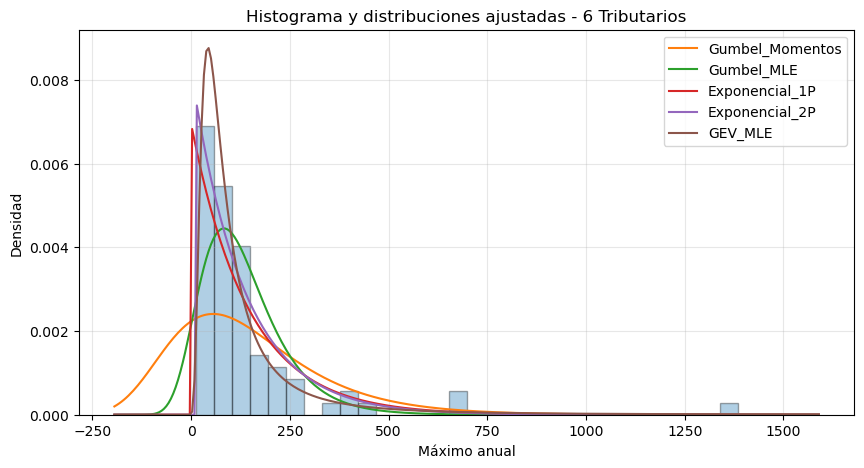

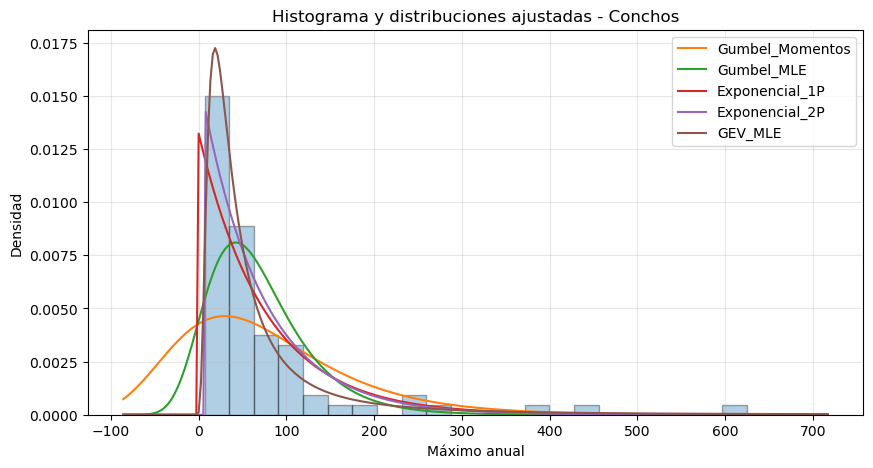

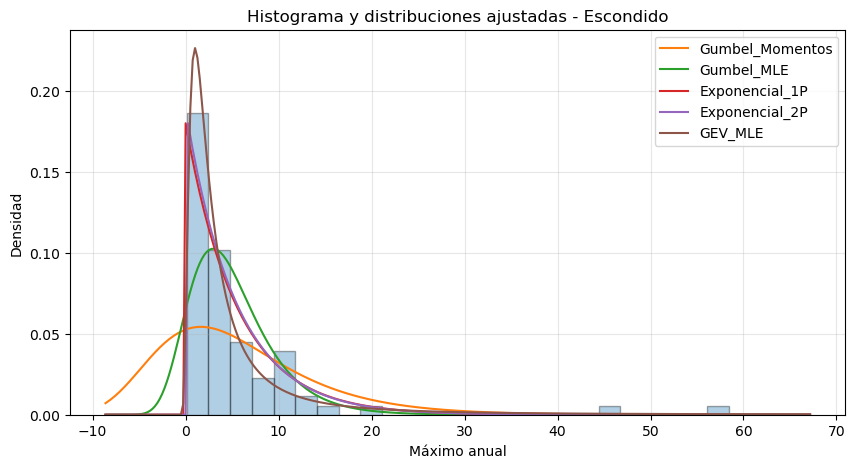

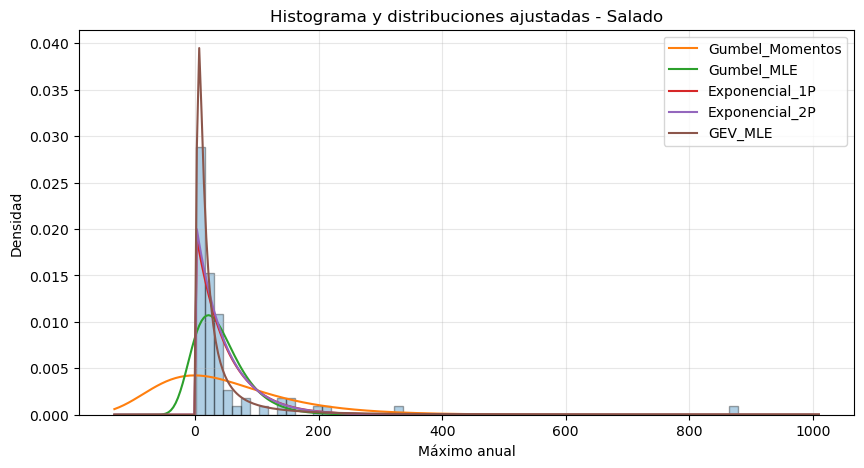

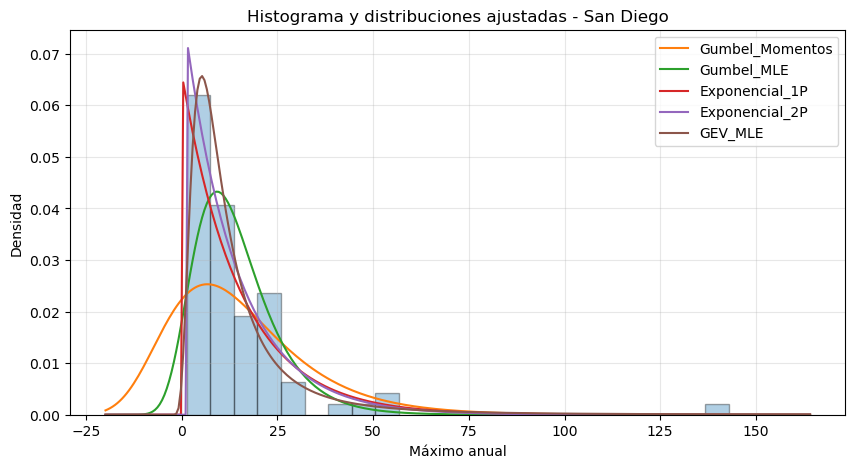

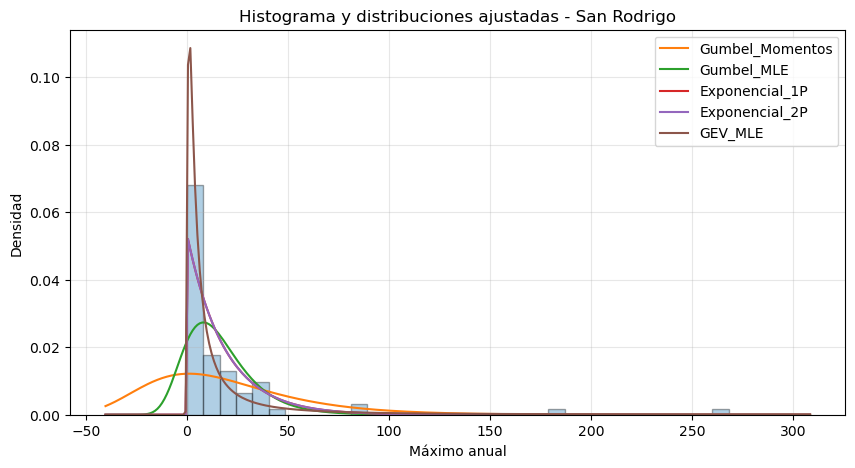

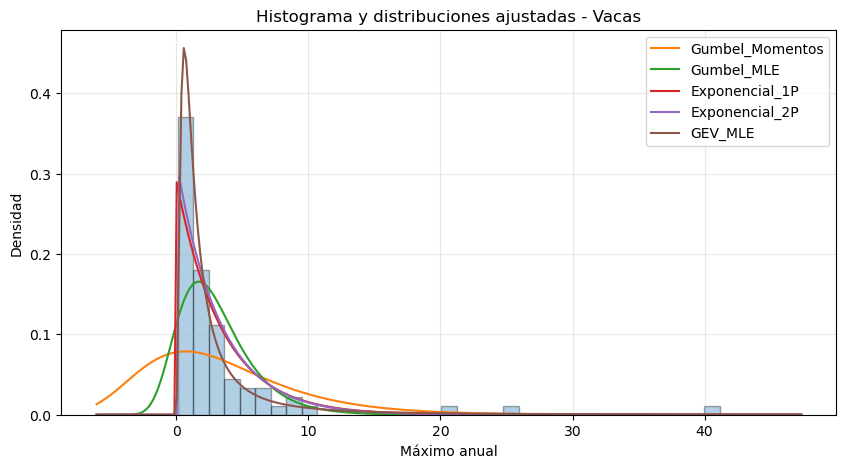

In [19]:
def graficar_histograma_ajustes(rio, datos, estimadores):
    datos = preparar_datos(datos)
    x_min = np.min(datos)
    x_max = np.max(datos)
    margen = 0.15 * (x_max - x_min) if x_max > x_min else 1
    x = np.linspace(x_min - margen, x_max + margen, 300)
    
    plt.figure(figsize=(10, 5))
    plt.hist(datos, bins="auto", density=True, alpha=0.35, edgecolor="black")
    
    for estimador in estimadores:
        try:
            est = estimador(datos)
            dist = get_scipy_distribution(est["scipy_dist"])
            y = dist.pdf(x, *est["scipy_params"])
            plt.plot(x, y, label=est["distribucion"])
        except Exception as e:
            print(f"No se pudo graficar {estimador.__name__} para {rio}: {e}")
    
    plt.title(f"Histograma y distribuciones ajustadas - {rio}")
    plt.xlabel("Máximo anual")
    plt.ylabel("Densidad")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


for rio, grupo in maximos_anuales.groupby("Rio"):
    graficar_histograma_ajustes(rio, grupo["Maximo_Anual"], estimadores)

# 17. Gráficas de periodo de retorno

Se grafica $Q_T$ contra $T$ para cada distribución.

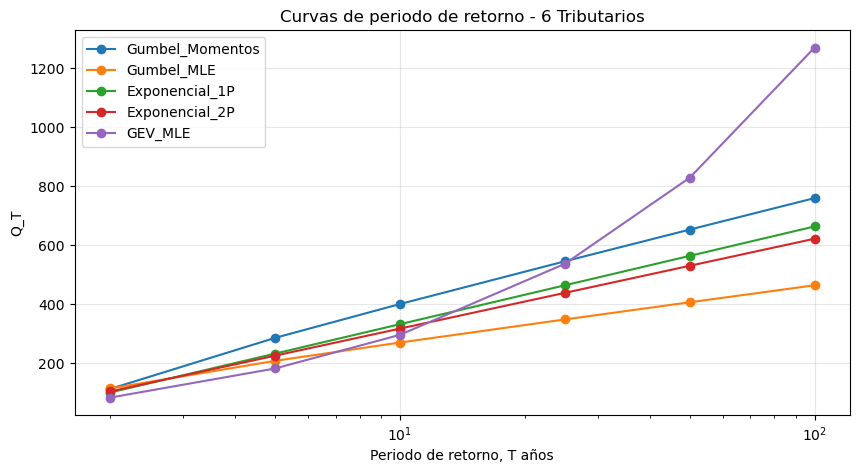

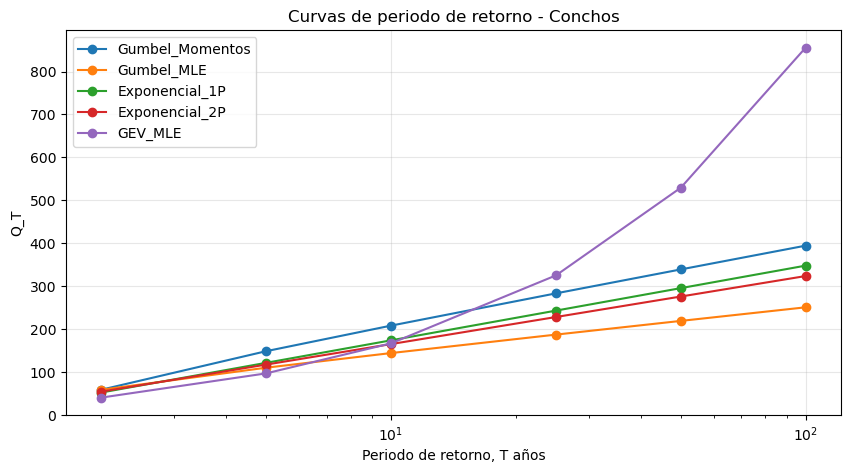

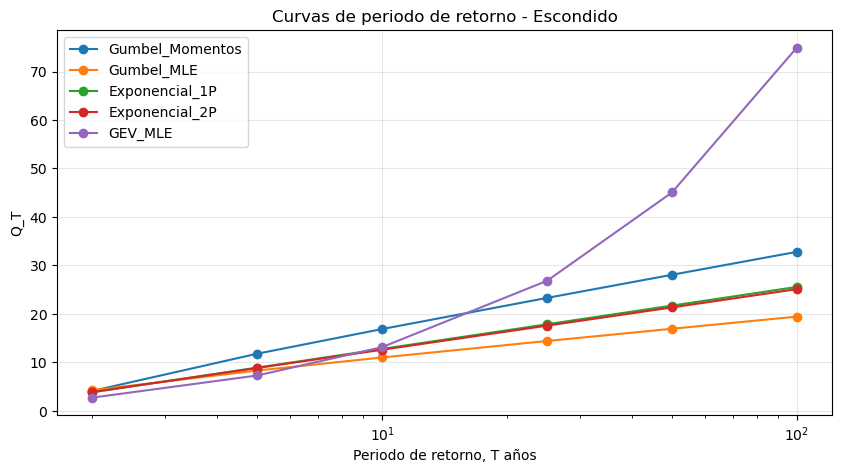

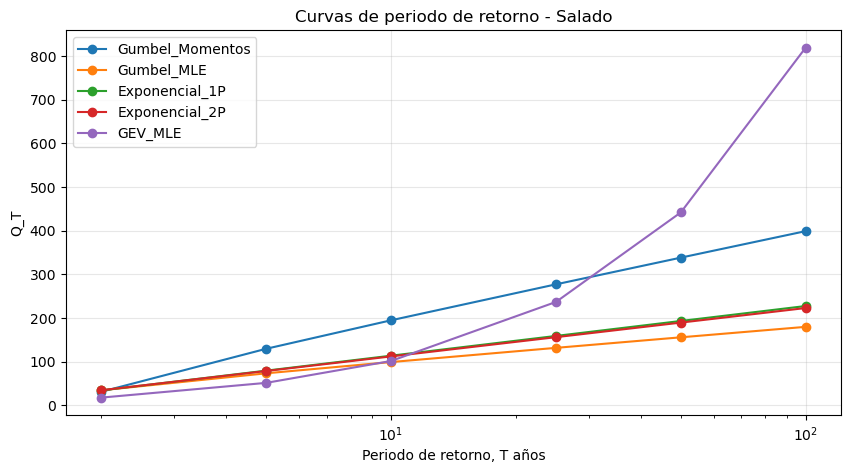

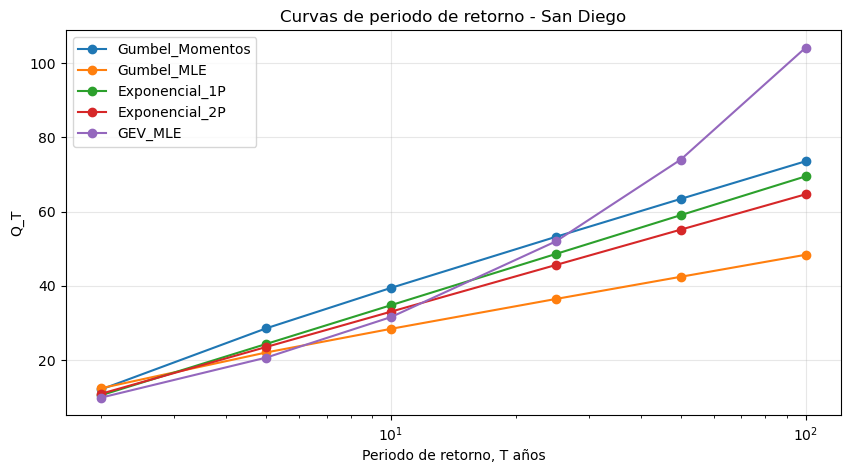

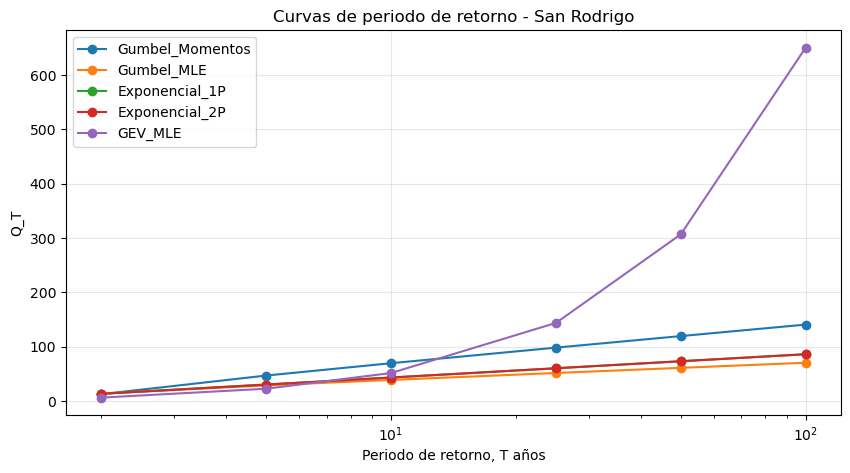

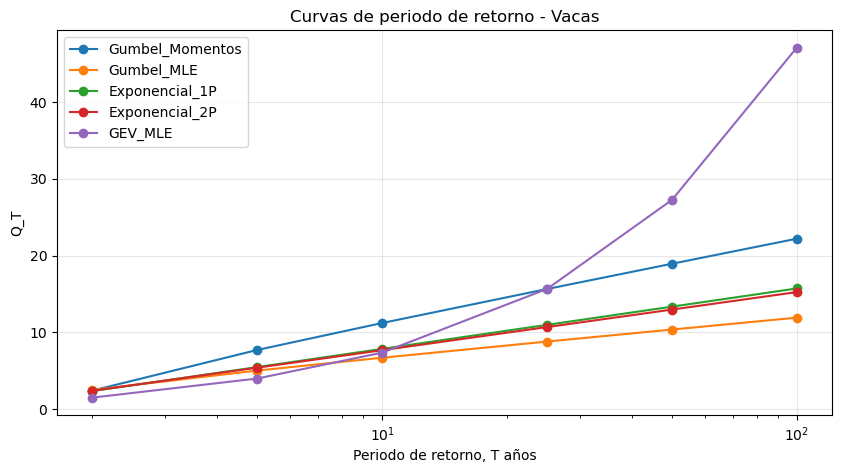

In [20]:
for rio in tabla_retorno["Rio"].unique():
    temp = tabla_retorno[tabla_retorno["Rio"] == rio]
    
    plt.figure(figsize=(10, 5))
    for _, row in temp.iterrows():
        q_vals = [row[f"Q_T_{T}"] for T in periodos_retorno]
        plt.plot(periodos_retorno, q_vals, marker="o", label=row["Distribucion"])
    
    plt.xscale("log")
    plt.title(f"Curvas de periodo de retorno - {rio}")
    plt.xlabel("Periodo de retorno, T años")
    plt.ylabel("Q_T")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# 18. Tabla final usando la mejor distribución por AIC

Esta tabla deja un resultado compacto por río: mejor distribución, métricas de ajuste y caudales de retorno.

In [21]:
tabla_final = mejor_por_aic.merge(
    tabla_retorno,
    on=["Rio", "Distribucion"],
    how="left"
)

tabla_final

,Rio,Distribucion,n,KS_stat,KS_pvalue,RMSE_prob,logLik,AIC,BIC,Q_T_2,Q_T_5,Q_T_10,Q_T_25,Q_T_50,Q_T_100
0,6 Tributarios,GEV_MLE,76,0.066748,0.864736,0.023377,-441.416566,888.833132,895.825332,82.419109,181.181183,295.078342,535.958928,827.628751,1268.613346
1,Conchos,GEV_MLE,76,0.053825,0.971866,0.022420,-395.701728,797.403456,804.395656,40.559498,97.046679,166.982840,325.312122,529.526648,855.743839
2,Escondido,GEV_MLE,76,0.080296,0.680952,0.034653,-202.669682,411.339364,418.331564,2.744473,7.308534,13.157443,26.846543,45.053698,74.928574
3,Salado,GEV_MLE,76,0.048792,0.989590,0.020436,-350.121198,706.242396,713.234596,17.770335,51.535413,101.633475,236.865895,441.879823,819.145930
4,San Diego,Exponencial_2P,76,0.076573,0.735136,0.027323,-275.204659,554.409318,559.070784,10.873156,23.473100,33.004590,45.604534,55.136023,64.667513
5,San Rodrigo,GEV_MLE,76,0.084041,0.625782,0.040444,-285.695104,577.390207,584.382407,5.922663,22.319561,51.185667,143.481834,306.598804,650.268391
6,Vacas,GEV_MLE,76,0.044170,0.996977,0.016419,-155.303765,316.607529,323.599729,1.519267,4.005876,7.369501,15.665277,27.244223,47.061677


# 19. Exportar resultados

Se guardan CSV y un Excel con varias hojas.

In [22]:
maximos_anuales.to_csv(OUTPUT_DIR / "01_maximos_anuales.csv", index=False)
validacion.to_csv(OUTPUT_DIR / "02_validacion.csv", index=False)
resumen.to_csv(OUTPUT_DIR / "03_resumen_descriptivo.csv", index=False)
tabla_parametros.to_csv(OUTPUT_DIR / "04_parametros_estimados.csv", index=False)
tabla_ajuste.to_csv(OUTPUT_DIR / "05_bondad_ajuste.csv", index=False)
tabla_retorno.to_csv(OUTPUT_DIR / "06_periodos_retorno.csv", index=False)
tabla_final.to_csv(OUTPUT_DIR / "07_tabla_final_mejor_aic.csv", index=False)

excel_salida = OUTPUT_DIR / "resultados_analisis_frecuencias.xlsx"

with pd.ExcelWriter(excel_salida, engine="openpyxl") as writer:
    maximos_anuales.to_excel(writer, sheet_name="Maximos_Anuales", index=False)
    validacion.to_excel(writer, sheet_name="Validacion", index=False)
    resumen.to_excel(writer, sheet_name="Resumen", index=False)
    tabla_parametros.to_excel(writer, sheet_name="Parametros", index=False)
    tabla_ajuste.to_excel(writer, sheet_name="Bondad_Ajuste", index=False)
    tabla_retorno.to_excel(writer, sheet_name="Retorno", index=False)
    tabla_final.to_excel(writer, sheet_name="Final_Mejor_AIC", index=False)

print(f"Resultados guardados en: {OUTPUT_DIR.resolve()}")
print(f"Excel consolidado: {excel_salida.resolve()}")

Resultados guardados en: C:\Users\luist\Desktop\entregas-Series\resultados_frecuencias
Excel consolidado: C:\Users\luist\Desktop\entregas-Series\resultados_frecuencias\resultados_analisis_frecuencias.xlsx


# 20. Texto base para reporte

Puedes adaptar este texto para tu documento.

## Metodología propuesta

A partir de los registros mensuales disponibles para cada tributario, se construyeron series de máximos anuales mediante el método de bloques máximos. Para cada año hidrológico disponible se seleccionó el valor máximo mensual registrado. Esta transformación permite modelar el comportamiento extremo de los caudales, en lugar de ajustar distribuciones directamente sobre observaciones mensuales que podrían presentar dependencia temporal y estacionalidad.

Posteriormente, para cada río se calcularon estadísticos descriptivos básicos: tamaño de muestra, mínimo, media, mediana, desviación estándar, máximo, asimetría, curtosis y coeficiente de variación. Estos indicadores permiten caracterizar la variabilidad y la presencia de valores extremos.

La estimación de parámetros se realizó para diferentes distribuciones de frecuencia: Gumbel por método de momentos, Gumbel por máxima verosimilitud, Exponencial de un parámetro, Exponencial de dos parámetros y GEV por máxima verosimilitud. La distribución Gumbel es frecuentemente utilizada para valores extremos, mientras que la GEV generaliza el comportamiento de máximos al incorporar un parámetro de forma. Las distribuciones exponenciales se incluyeron como modelos alternativos de cola decreciente.

La bondad de ajuste se evaluó mediante la prueba de Kolmogorov-Smirnov, el error cuadrático medio entre probabilidades empíricas y teóricas, y criterios de información AIC y BIC. Finalmente, se calcularon caudales asociados a periodos de retorno de 2, 5, 10, 25, 50 y 100 años usando la relación $F(Q_T)=1-1/T$.

# 21. Nota sobre TCEV

La distribución TCEV, o Two-Component Extreme Value, representa los máximos como la combinación de dos mecanismos generadores de eventos: eventos ordinarios y eventos extraordinarios. Es útil cuando los extremos no parecen provenir de una sola población hidrológica.

Sin embargo, su ajuste es más delicado porque tiene más parámetros que Gumbel o GEV. Si la muestra es pequeña, el modelo puede sobreajustarse o producir parámetros inestables. Por eso, para una entrega inicial seria, conviene reportar primero Gumbel, Exponencial y GEV, y dejar TCEV como extensión avanzada si el profesor la exige explícitamente.